In [214]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

Load the dataset and display:

First 5 rows  
Shape  
Column types  

In [215]:
df = pd.read_csv(r"C:\Users\mxrmx\Desktop\Career\Stats\m3w1s3_grocery_store_data.csv", encoding="Latin")

In [216]:
df.head()

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32


In [217]:
df.shape

(25000, 6)

In [218]:
df.dtypes

Customer_ID             int64
Store_ID               object
Transaction_Amount    float64
Basket_Size             int64
Visit_Day              object
Customer_Age            int64
dtype: object

Check:

Missing values  
Unique values in Store_ID and Visit_Day  

In [219]:
df.head()

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32


In [220]:
df.isnull().sum()

Customer_ID           0
Store_ID              0
Transaction_Amount    0
Basket_Size           0
Visit_Day             0
Customer_Age          0
dtype: int64

In [221]:
df["Store_ID"].unique()

array(['S001', 'S004', 'S002', 'S003'], dtype=object)

In [222]:
df["Visit_Day"].unique()

array(['Thu', 'Fri', 'Sun', 'Tue', 'Wed', 'Sat', 'Mon'], dtype=object)

Find the mean Transaction Amount

In [223]:
df.head()

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32


In [224]:
print(df["Transaction_Amount"].mean())

75.02023080000001


Find mean Transaction Amount:

Per Store_ID   
Per Visit_Day  

In [225]:
df.groupby("Store_ID")["Transaction_Amount"].mean().reset_index().rename(columns={"Transaction_Amount":"Avg_Transaction_Amount"})

,Store_ID,Avg_Transaction_Amount
0,S001,75.191684
1,S002,75.257383
2,S003,74.627236
3,S004,75.003663


In [226]:
df.groupby("Visit_Day")["Transaction_Amount"].mean().reset_index().rename(columns= {"Transaction_Amount":"Avg_Transaction_Amount"})

,Visit_Day,Avg_Transaction_Amount
0,Fri,74.905804
1,Mon,74.847254
2,Sat,75.678271
3,Sun,74.391620
4,Thu,75.115612
5,Tue,75.220323
6,Wed,74.980282


Which store has the highest average transaction value?

In [227]:
df.head()

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32


In [228]:
df.groupby("Store_ID")["Transaction_Amount"].mean().reset_index().sort_values(by="Transaction_Amount",ascending=False).head(1)

,Store_ID,Transaction_Amount
1,S002,75.257383


If one transaction = ₹1,00,000 is to 1 row added:  

What happens to mean?

In [229]:
df.head()

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32


In [230]:
df.shape

(25000, 6)

In [231]:
new_row = {"Customer_ID":99999,
           "Store_ID":"S002",
           "Transaction_Amount":100000,
           "Basket_Size":4,
           "Visit_Day":"Sat",
           "Customer_Age":40}


In [232]:
df_new = pd.DataFrame([new_row])

In [233]:
df_new = pd.concat([df,df_new])

In [234]:
df_new.tail(1)

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,99999,S002,100000.0,4,Sat,40


In [235]:
df_new["Transaction_Amount"].mean()

np.float64(79.01707011719532)

In [236]:
df_new["Transaction_Amount"].mean() - df["Transaction_Amount"].mean()

np.float64(3.9968393171953096)

Find median Transaction Amount

In [237]:
df["Transaction_Amount"].median()

75.06

Compare:

Mean vs Median of Transaction Amount
What does the difference indicate?

In [238]:
df["Transaction_Amount"].median() - df["Transaction_Amount"].mean()

np.float64(0.03976919999999495)

the data indicates that the data is left skewed which is negatively skewed

Find median Basket_Size per Store_ID

In [239]:
df.groupby("Store_ID")["Basket_Size"].median().reset_index()

,Store_ID,Basket_Size
0,S001,5.0
1,S002,5.0
2,S003,5.0
3,S004,5.0


Find:

Most common Visit_Day
Most common Basket_Size

In [240]:
df["Visit_Day"].mode() #mode - Frequently occuring values in the dataset 

0    Mon
Name: Visit_Day, dtype: object

In [241]:
df["Basket_Size"].mode()

0    4
Name: Basket_Size, dtype: int64

Find mode of Store_ID → Which store gets most visits?

In [242]:
df["Store_ID"].mode()

0    S002
Name: Store_ID, dtype: object

Plot boxplot of Transaction_Amount

<Axes: ylabel='Transaction_Amount'>

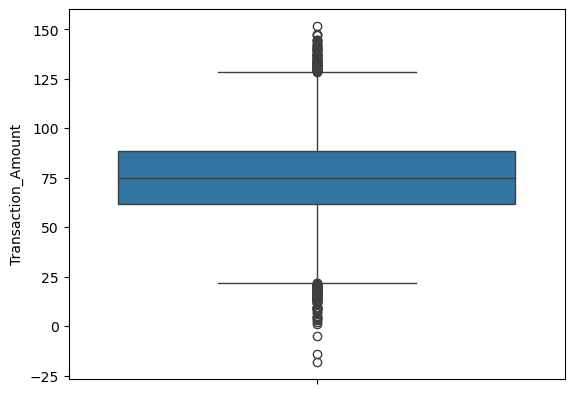

In [243]:
sns.boxplot(df["Transaction_Amount"])

Identify outliers using:  

IQR method

In [244]:
df.shape

(25000, 6)

In [245]:
q1 = df["Transaction_Amount"].quantile(0.25)
q2 = df["Transaction_Amount"].quantile(0.5)
q3 = df["Transaction_Amount"].quantile(0.75)
print(q1)
print(q2)
print(q3)

61.71
75.06
88.41


In [246]:
IQR = q3 - q1
print(IQR)

26.699999999999996


In [248]:
lower_fense = q1 - (1.5*IQR)
upper_fense = q3 + (1.5*IQR)
print(lower_fense)
print(upper_fense)

21.660000000000004
128.45999999999998


In [251]:
outliers = df[(df["Transaction_Amount"] < lower_fense) | (df["Transaction_Amount"] > upper_fense)]
outliers

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
25,26,S002,20.09,2,Sun,41
77,78,S001,132.30,3,Thu,30
200,201,S002,18.94,6,Thu,36
417,418,S001,139.41,3,Fri,42
904,905,S001,133.01,4,Tue,31
...,...,...,...,...,...,...
24660,24661,S001,130.65,5,Tue,37
24746,24747,S003,14.83,8,Sat,22
24852,24853,S003,135.95,4,Thu,37
24854,24855,S003,7.35,6,Tue,56


value below lower bounds indicates outliers 
value below upper bound indiacates outliers 

Remove outliers and recompute:

Mean  
Median  

In [253]:
clean_df = df[(df["Transaction_Amount"]>=lower_fense) & (df["Transaction_Amount"]<=upper_fense)]

In [254]:
clean_df

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32
...,...,...,...,...,...,...
24995,24996,S004,102.24,6,Mon,45
24996,24997,S001,47.09,5,Mon,23
24997,24998,S003,72.37,5,Tue,38
24998,24999,S004,66.39,5,Thu,32


In [255]:
clean_df["Transaction_Amount"].mean()

np.float64(75.04479814478725)

In [256]:
clean_df["Transaction_Amount"].median()

75.07

In [257]:
df["Transaction_Amount"].mean()

np.float64(75.02023080000001)

In [258]:
df["Transaction_Amount"].median()

75.06

Range=Max−Min

Q16

Find range of:

Transaction_Amount
Customer_Age

In [259]:
range_txn = df["Transaction_Amount"].max() - df["Transaction_Amount"].min()
range_txn

169.83999999999997

In [261]:
range_age = df["Customer_Age"].max() - df["Customer_Age"].min()
range_age

51

Which variable is more spread out?

In [266]:
df.dtypes

Customer_ID             int64
Store_ID               object
Transaction_Amount    float64
Basket_Size             int64
Visit_Day              object
Customer_Age            int64
dtype: object

In [264]:
df.std(numeric_only=True)

Customer_ID           7217.022701
Transaction_Amount      19.977965
Basket_Size              2.249787
Customer_Age            15.064971
dtype: float64

Transaction_Amount is most spread out in all numeric column. exluding customer_id it wont matter 

Why is range unreliable for this dataset?

range gives differnce between max and min value, where as standard deviation considers distance of each value from the mean. hence, st.deviattion is better measure to find out how reliable the dataset is 

Concept: Spread using squared deviations (page 29)

Q19

Compute variance of:

Transaction_Amount
Customer_Age

In [269]:
var_tnx = df["Transaction_Amount"].var()
var_tnx

399.11906916949516

In [270]:
var_age = df["Customer_Age"].var()
var_age

226.95334488420193

Which feature is more volatile?

more volatile - less reliable 

# Transaction Amount column have greater variance(399) hence it is more volatile

Compare std deviation across stores

In [273]:
df.groupby("Store_ID")["Transaction_Amount"].std().sort_values(ascending=False)

Store_ID
S002    20.292766
S004    19.940429
S001    19.894279
S003    19.777187
Name: Transaction_Amount, dtype: float64

Which is more robust to outliers? MAD vs. STD

CV=
μ/σ
	


Q27

Compute CV for:

Transaction_Amount

COV for each store id

Histogram of Transaction_Amount

<Axes: xlabel='Transaction_Amount', ylabel='Count'>

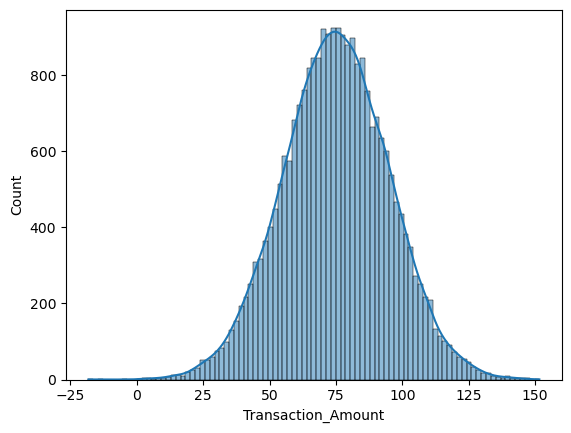

In [278]:
sns.histplot(df["Transaction_Amount"],kde=True)

most of the transation amount lie between 50-100
it forms bell shape curve and it is a perfect curve
the peak denotes mean/median 

Boxplot of Transaction_Amount per Store

<Axes: xlabel='Store_ID', ylabel='Transaction_Amount'>

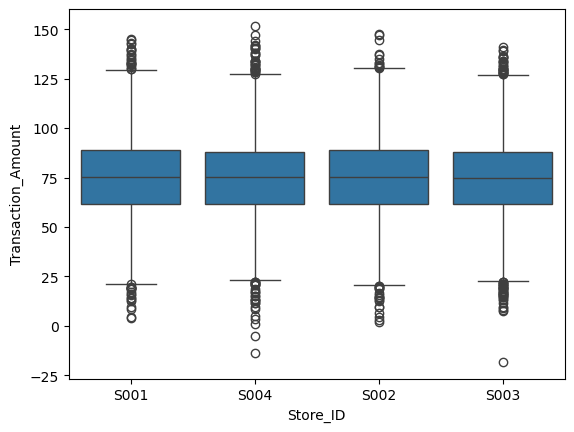

In [281]:
sns.boxplot(x="Store_ID",y="Transaction_Amount",data=df)

Should the company use:

Mean or Median to define "average customer spend"?

In [282]:
df["Transaction_Amount"].mean()

np.float64(75.02023080000001)

In [ ]:
df["Transaction_Amount"].median()

75.06

The numbers are identical: Both options give the same answer (~$75).No outlier distortion: Big spenders are not messing up the average.Best for business: Mean tracks total revenue perfectly.

Which day has:

Highest spending customers?

In [284]:
df.head()

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32


In [293]:
df.groupby("Visit_Day")["Transaction_Amount"].sum().sort_values(ascending=False).reset_index().head(1)

,Visit_Day,Transaction_Amount
0,Mon,276336.06


Which store:

Has consistent customers (low variance)?

In [294]:
df.head()

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32


In [298]:
df.groupby("Store_ID")["Transaction_Amount"].var().sort_values().head(1).reset_index()

,Store_ID,Transaction_Amount
0,S003,391.137114
